# Comprensión y EDA — Análisis Exploratorio de Datos

Dataset de créditos financieros con el objetivo de predecir si un cliente pagará a tiempo (`Pago_atiempo`).  
Se trabaja sobre el CSV generado por `Cargar_datos.ipynb`.


---
## Parte 1 — Exploración Inicial de Datos


### 1.1 Importar librerías


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


### 1.2 Cargar el dataset


In [109]:
df = pd.read_csv('../../Base_de_datos.csv')
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()


Filas: 10763 | Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


### 1.3 Descripción general y caracterización de variables

El dataset tiene **23 columnas** que se clasifican así:

| Tipo de variable         | Variables                                                                 |
|-------------------------|---------------------------------------------------------------------------|
| **Numéricas**           | capital_prestado, salario_cliente, cuota_pactada, puntaje, puntaje_datacredito, saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor, promedio_ingresos_datacredito, plazo_meses, edad_cliente, total_otros_prestamos, cant_creditosvigentes, huella_consulta, creditos_sectorFinanciero, creditos_sectorCooperativo, creditos_sectorReal |
| **Categóricas**         | tipo_laboral, tendencia_ingresos, tipo_credito                            |
| **Dicotómica (target)** | Pago_atiempo                                                              |
| **Fecha**               | fecha_prestamo                                                            |


In [110]:
df.dtypes


tipo_credito                       int64
fecha_prestamo                    object
capital_prestado                 float64
plazo_meses                        int64
edad_cliente                       int64
tipo_laboral                      object
salario_cliente                    int64
total_otros_prestamos              int64
cuota_pactada                      int64
puntaje                          float64
puntaje_datacredito              float64
cant_creditosvigentes              int64
huella_consulta                    int64
saldo_mora                       float64
saldo_total                      float64
saldo_principal                  float64
saldo_mora_codeudor              float64
creditos_sectorFinanciero          int64
creditos_sectorCooperativo         int64
creditos_sectorReal                int64
promedio_ingresos_datacredito    float64
tendencia_ingresos                object
Pago_atiempo                       int64
dtype: object

### 1.4 Revisión de valores nulos


In [111]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)


,Nulos,Porcentaje (%)
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


**Interpretación:**  
- `promedio_ingresos_datacredito` y `tendencia_ingresos` tienen ~27% de nulos — probablemente son clientes sin historial en Datacredito.  
- `saldo_mora_codeudor` tiene ~5.5% nulos — posiblemente el crédito no tiene codeudor.  
- `saldo_principal` 3.8% y `saldo_mora`/`saldo_total` 1.5% — se deberán imputar o marcar.  
- `puntaje_datacredito` tiene solo 6 nulos — negligible.


### 1.5 Limpieza y corrección de datos

**Corrección de tipos:** `tipo_credito` es numérico pero representa categorías. `fecha_prestamo` debe ser datetime.


In [112]:
#1. Convertir fecha_prestamo a datetime
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'])

# 2. Convertir tipo_credito a categoría (es un código, no un número)
df['tipo_credito'] = df['tipo_credito'].astype('category')

# 3. Convertir tipo_laboral y tendencia_ingresos a categoría
df['tipo_laboral']      = df['tipo_laboral'].astype('category')
df['tendencia_ingresos'] = pd.Categorical(
    df['tendencia_ingresos'],
    categories=['Decreciente', 'Estable', 'Creciente'],
    ordered=True
)


print("Tipos de datos corregidos:")
print(df.dtypes)


Tipos de datos corregidos:
tipo_credito                           category
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingr

In [113]:
df['saldo_mora_codeudor'].value_counts(dropna=False)

saldo_mora_codeudor
0.0       10170
NaN         590
2145.0        1
30.0          1
470.0         1
Name: count, dtype: int64

### 1.6 Eliminamos columnas irrelevantes para el analisis
saldo mora codeudor tiene 10mil 0.0 590 nan yy solo 3 con valores reales.
saldo mora igual
creditos sector cooperativo tiene 8mil 0 lo eliminamos ya que no va a aportar
creditos sector real tiene 4 mil 0 por lo tanto tambien eliminamos ya que no aportara valor al analisis. 
tipo credito no se entiende de donde viene y puede cesgar al modelo. Considero que no aporta al analisis.

In [115]:
df = df.drop(['tendencia_ingresos', 'tipo_credito', 'creditos_sectorFinanciero',
               'promedio_ingresos_datacredito', 'saldo_mora_codeudor',
                 'saldo_mora', 'creditos_sectorCooperativo', 'creditos_sectorReal'], axis=1)

### 1.7 tratamiento de 0 o NaN
saldo total y saldo principal hay que mantenerlos pero tratar nulos y 0.0 que es lo mismo


In [116]:
#Cambiamos todos los NaN por 0 en las columnas de saldo_total, saldo_principal y puntaje_datacredito.
df[['saldo_total', 'saldo_principal','puntaje_datacredito']] = df[['saldo_total', 'saldo_principal','puntaje_datacredito']].fillna(0)

In [ ]:
#Imputamos saldo total y saldo principal con la media de cada columna, 
# pero solo para los casos donde el valor es 0, 
# ya que asumimos que 0 no es un valor realista para estas variables.
for col in ['saldo_total', 'saldo_principal']:
    media = df.loc[df[col] != 0, col].mean()
    df.loc[df[col] == 0, col] = media

---
## Parte 2 — EDA: Análisis Univariable


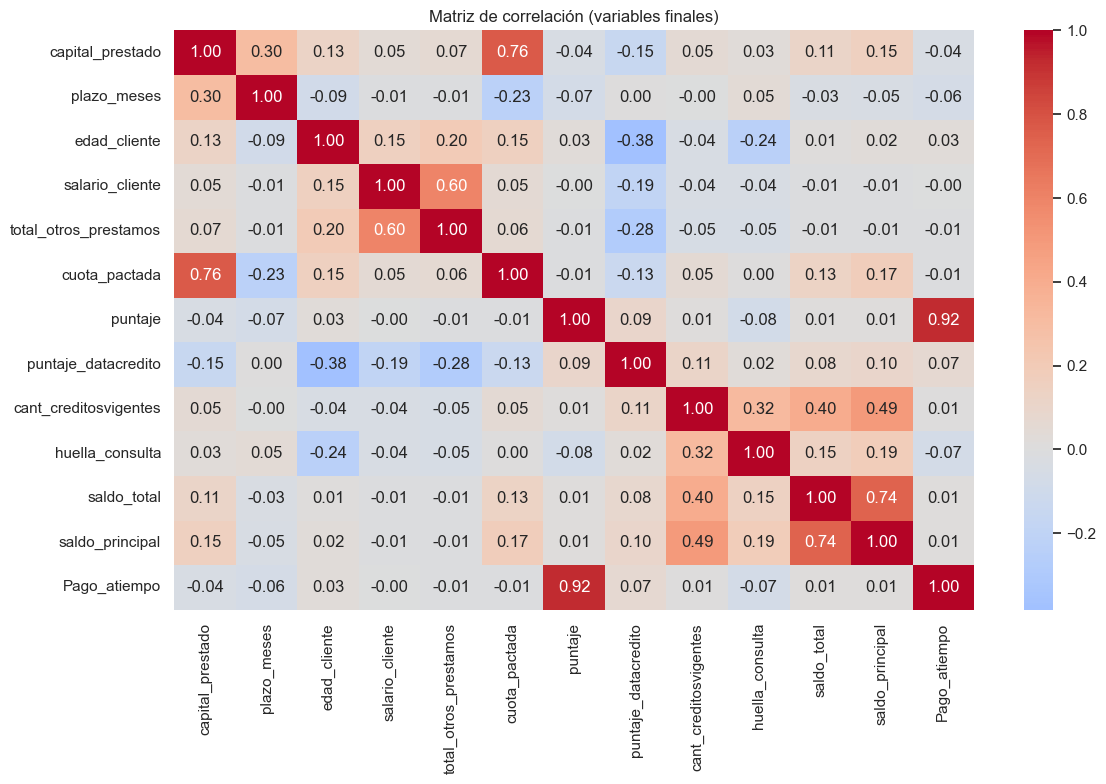

In [ ]:
# Matriz de correlación de las variables numericas
corr_final = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_final, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables numericas)")
plt.tight_layout()
plt.show()

### Puntaje tiene una correlacion muy alta con respecto a la variable objetivo. Lo que puede hacer que el modelo sea cesgado. 

In [123]:
df.describe()


,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_total,saldo_principal,Pago_atiempo
count,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10763.000000,10763.000000,10763.000000,1.076300e+04,1.076300e+04,10763.000000
mean,2025-04-16 23:06:02.111121664,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.355570,5.726749,4.228561,4.527159e+04,3.882799e+04,0.952523
min,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,2.570000e+03,2.008000e+03,1.000000
50%,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,1.558100e+04,1.302600e+04,1.000000
75%,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,5.215600e+04,4.529700e+04,1.000000
max,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,5.116066e+06,1.562285e+06,1.000000
std,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,106.456382,3.977162,3.064683,1.056395e+05,7.030957e+04,0.212668


### 2.1 Estadísticas descriptivas — Variables numéricas


In [119]:
cols_numericas = df.select_dtypes(include='number').columns.tolist()
desc = df[cols_numericas].describe().T
desc['skewness'] = df[cols_numericas].skew()
desc['kurtosis'] = df[cols_numericas].kurt()
desc


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07,3.723884,35.318092
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01,2.459691,7.780121
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02,1.934399,7.868936
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10,43.776664,2211.230120
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09,38.463886,1719.280871
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06,3.793301,26.650757
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01,-4.865607,24.081011
puntaje_datacredito,10763.0,7.803556e+02,1.064564e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02,-5.601880,38.476524
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01,1.797738,8.623346
huella_consulta,10763.0,4.228561e+00,3.064683e+00,0.00000,2.000000e+00,4.000000e+00,6.000000e+00,2.900000e+01,1.487102,3.998984


### 2.2 Histogramas — Variables numéricas


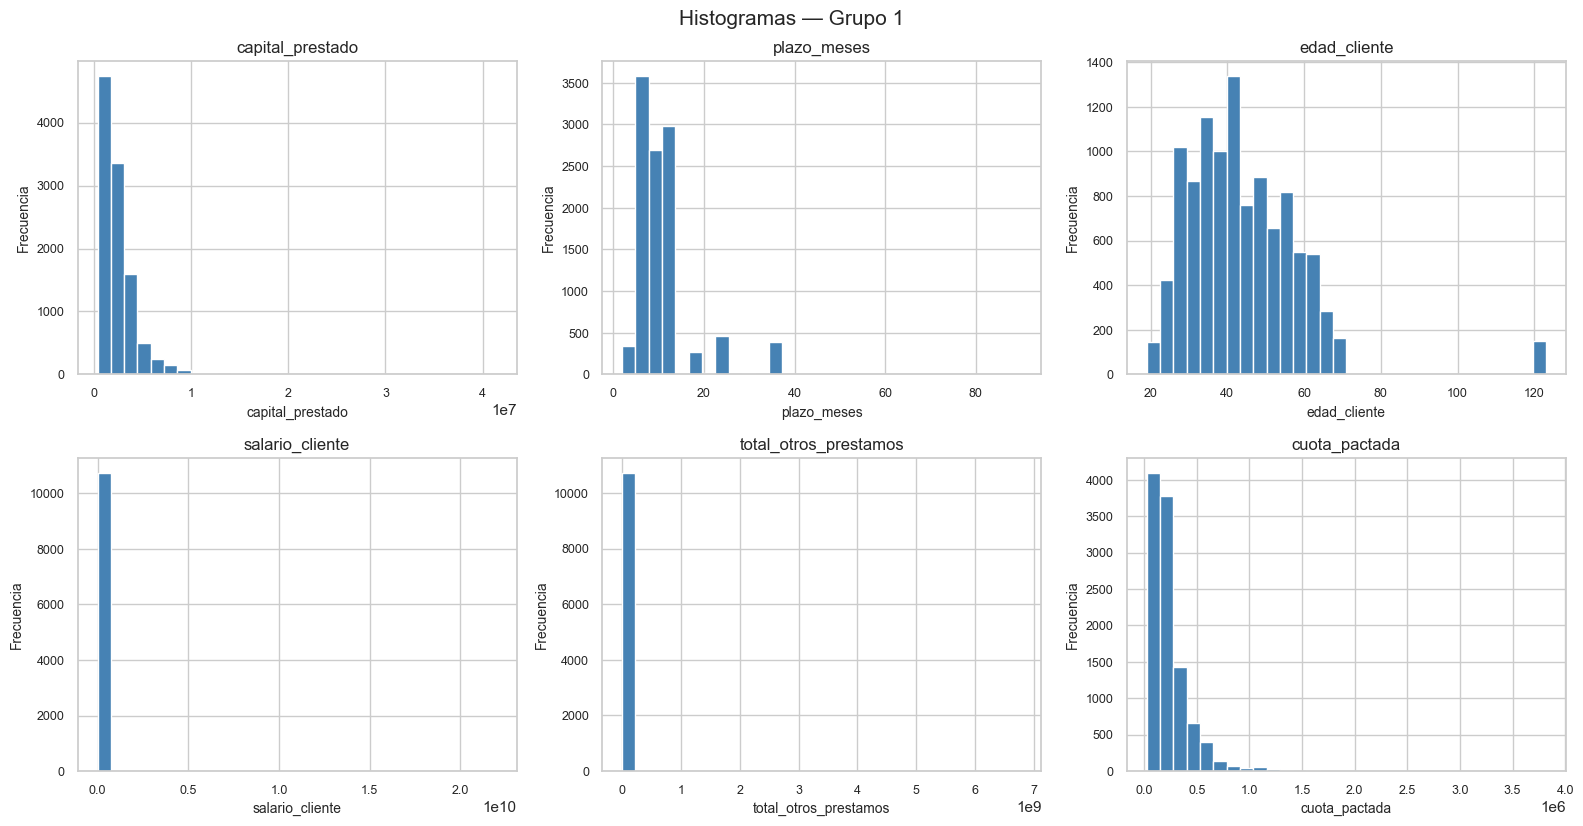

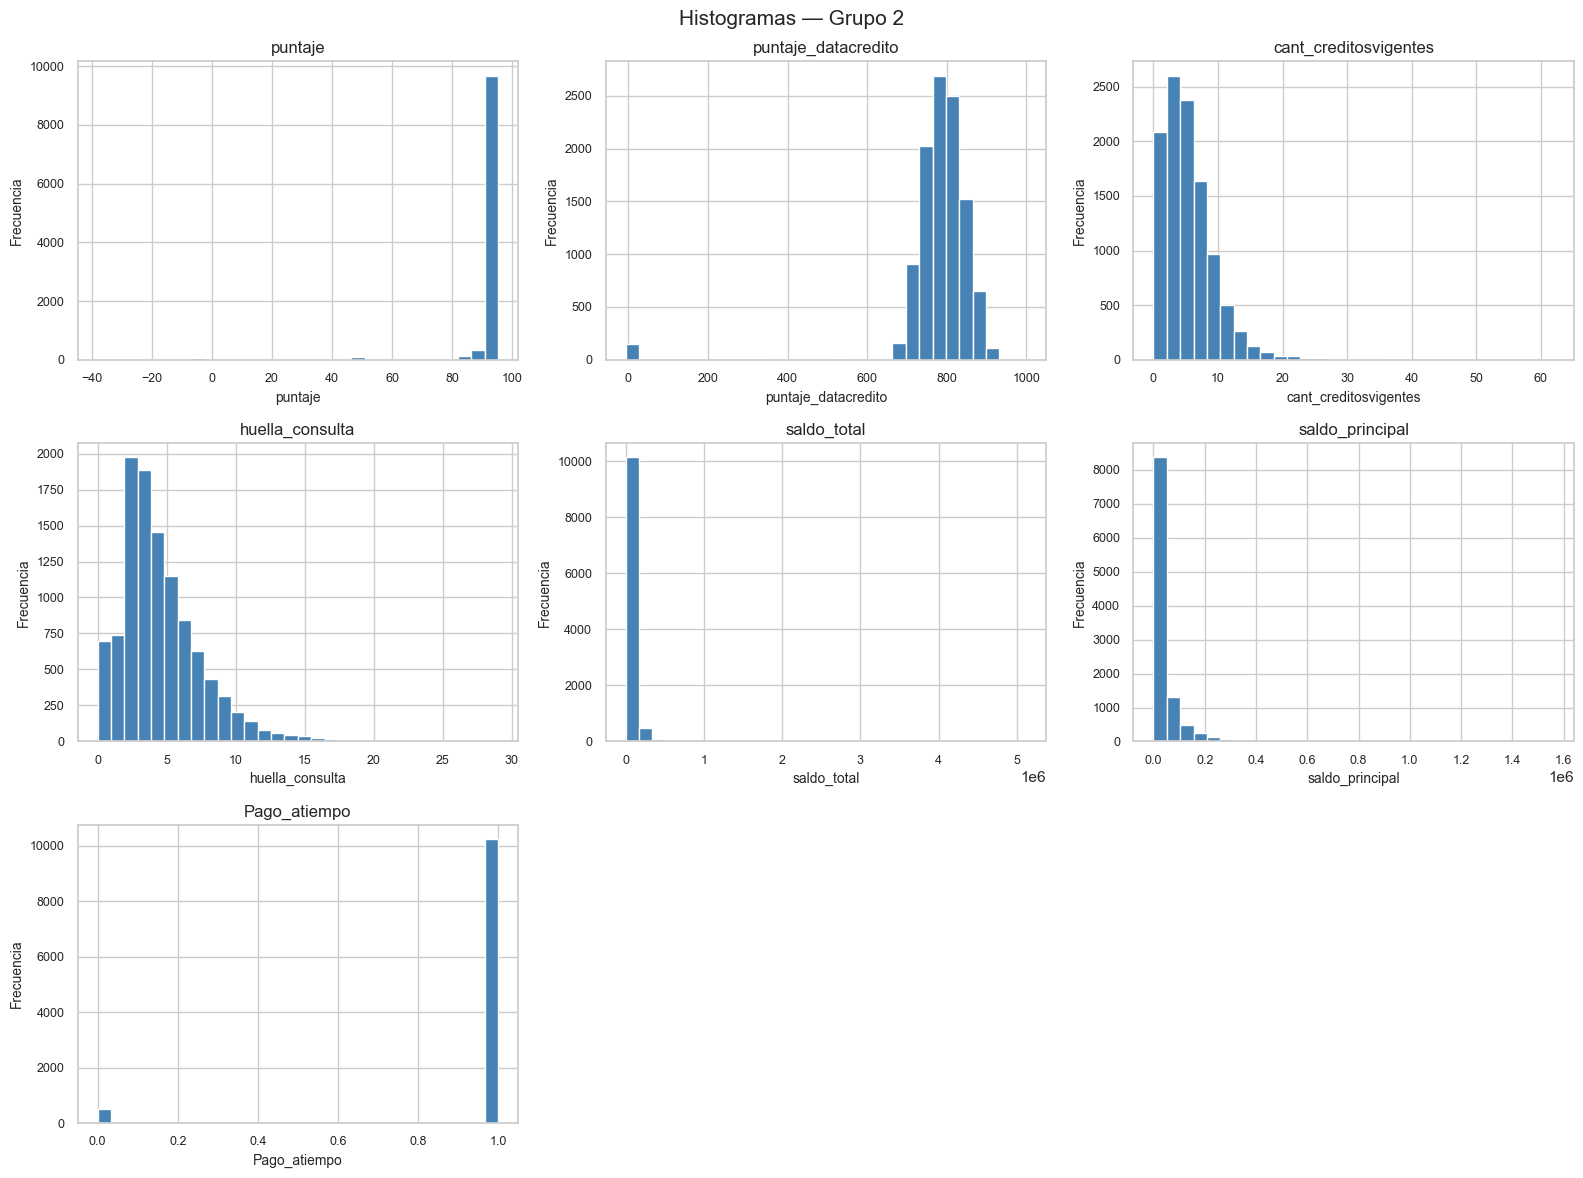

In [121]:
mitad = len(cols_numericas) // 2
grupos = [cols_numericas[:mitad], cols_numericas[mitad:]]

for idx, grupo in enumerate(grupos):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
    axes = axes.flatten()
    for i, col in enumerate(grupo):
        df[col].dropna().hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white')
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Frecuencia', fontsize=10)
        axes[i].tick_params(axis='x', labelsize=9)
        axes[i].tick_params(axis='y', labelsize=9)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'Histogramas — Grupo {idx+1}', fontsize=15)
    plt.tight_layout()
    plt.show()


**Interpretación:** La mayoría de variables financieras (`saldo_total, `saldo_principal`, `puntaje`, 'total otros prestamos', y ' salario_cliente') presentan distribución con alta asimetría positiva o negativa. Esto indica outliers hacia los valores altos o muy bajos. veremos como se comportan para tratarlos. Ademas puntaje tiene mucha correlacion con respecto a la variable objetivo (pago a tiempo).


### 2.3 Boxplots — Variables numéricas (detección de outliers)


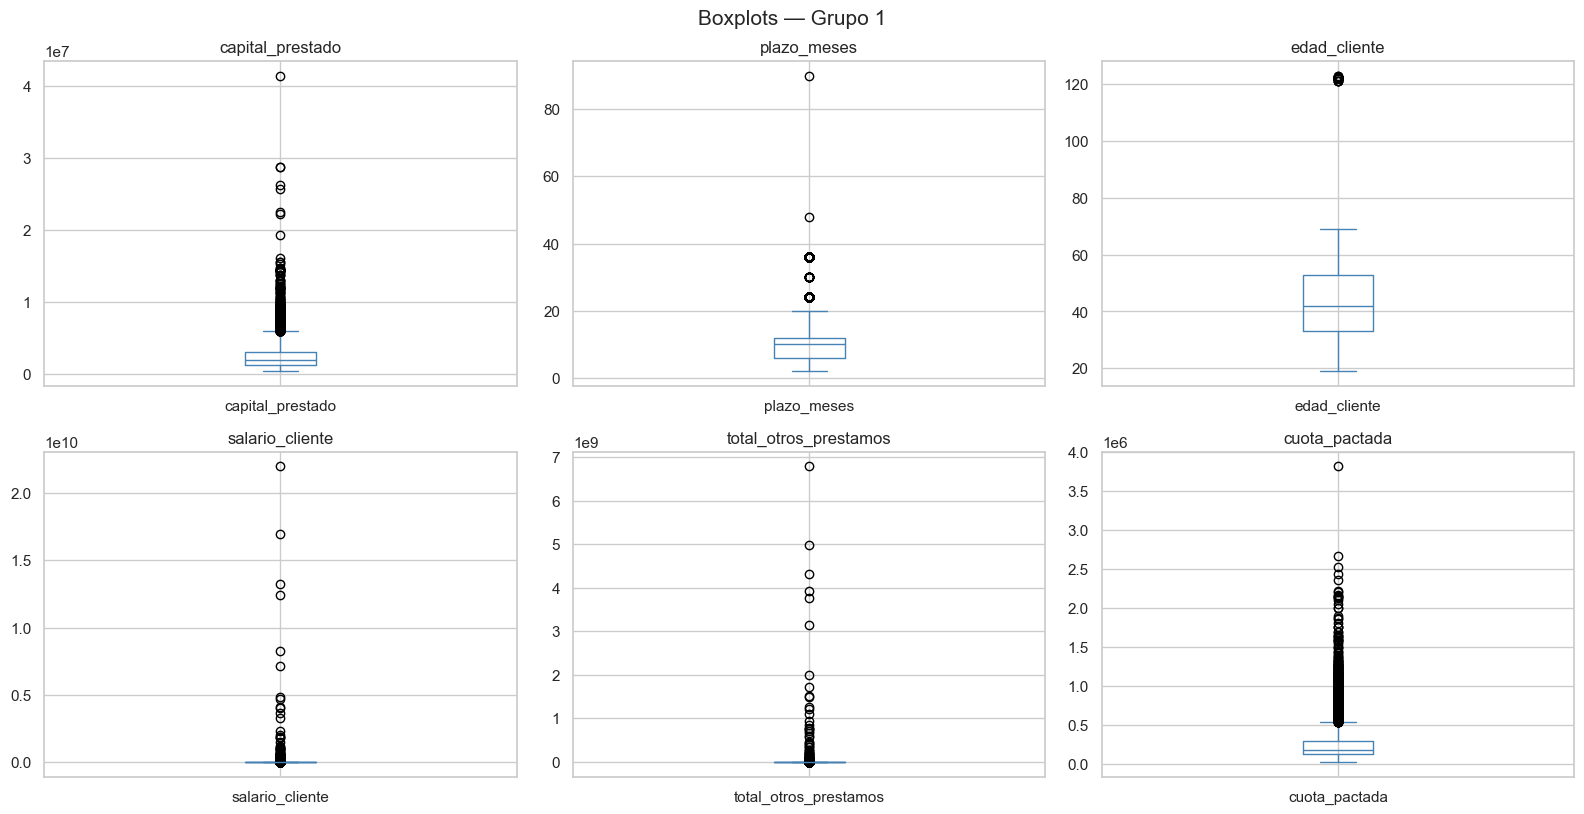

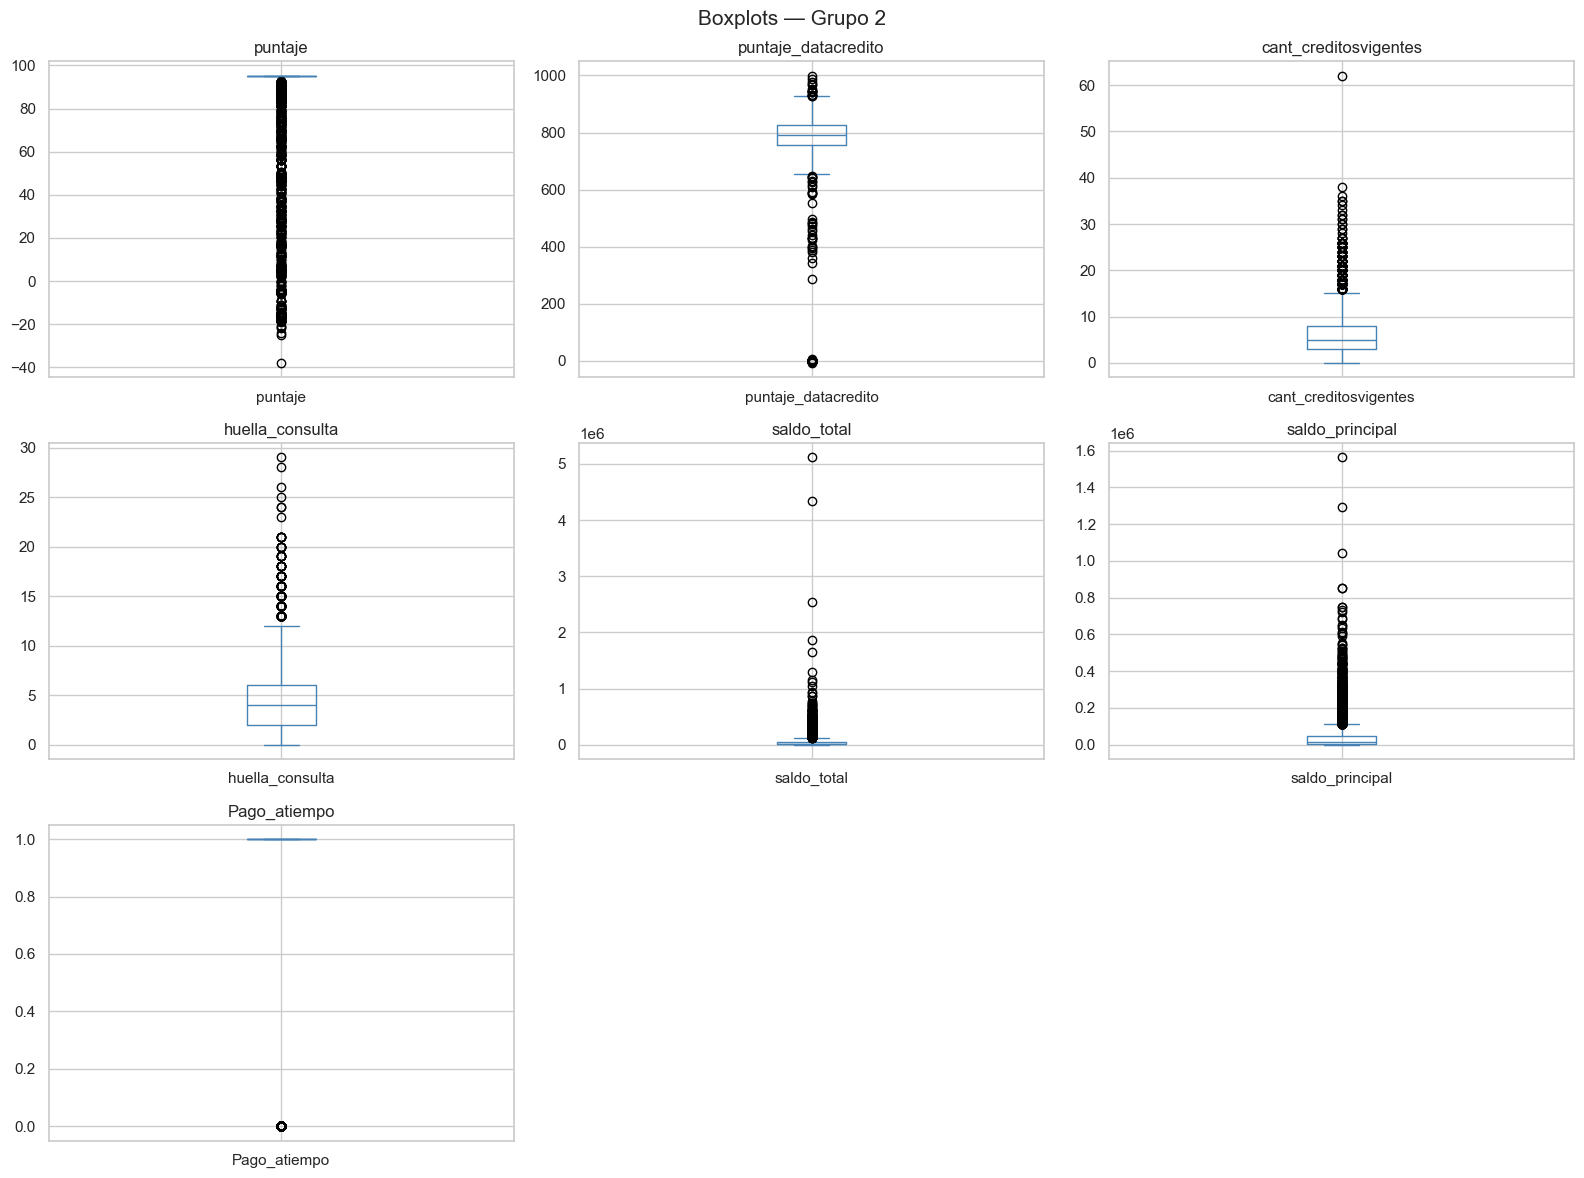

In [125]:
for idx, grupo in enumerate(grupos):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
    axes = axes.flatten()
    for i, col in enumerate(grupo):
        df[col].dropna().plot(kind='box', ax=axes[i], color='steelblue')
        axes[i].set_title(col, fontsize=12)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'Boxplots — Grupo {idx+1}', fontsize=15)
    plt.tight_layout()
    plt.show()


### 2.4 Variables categóricas — Conteos y distribución


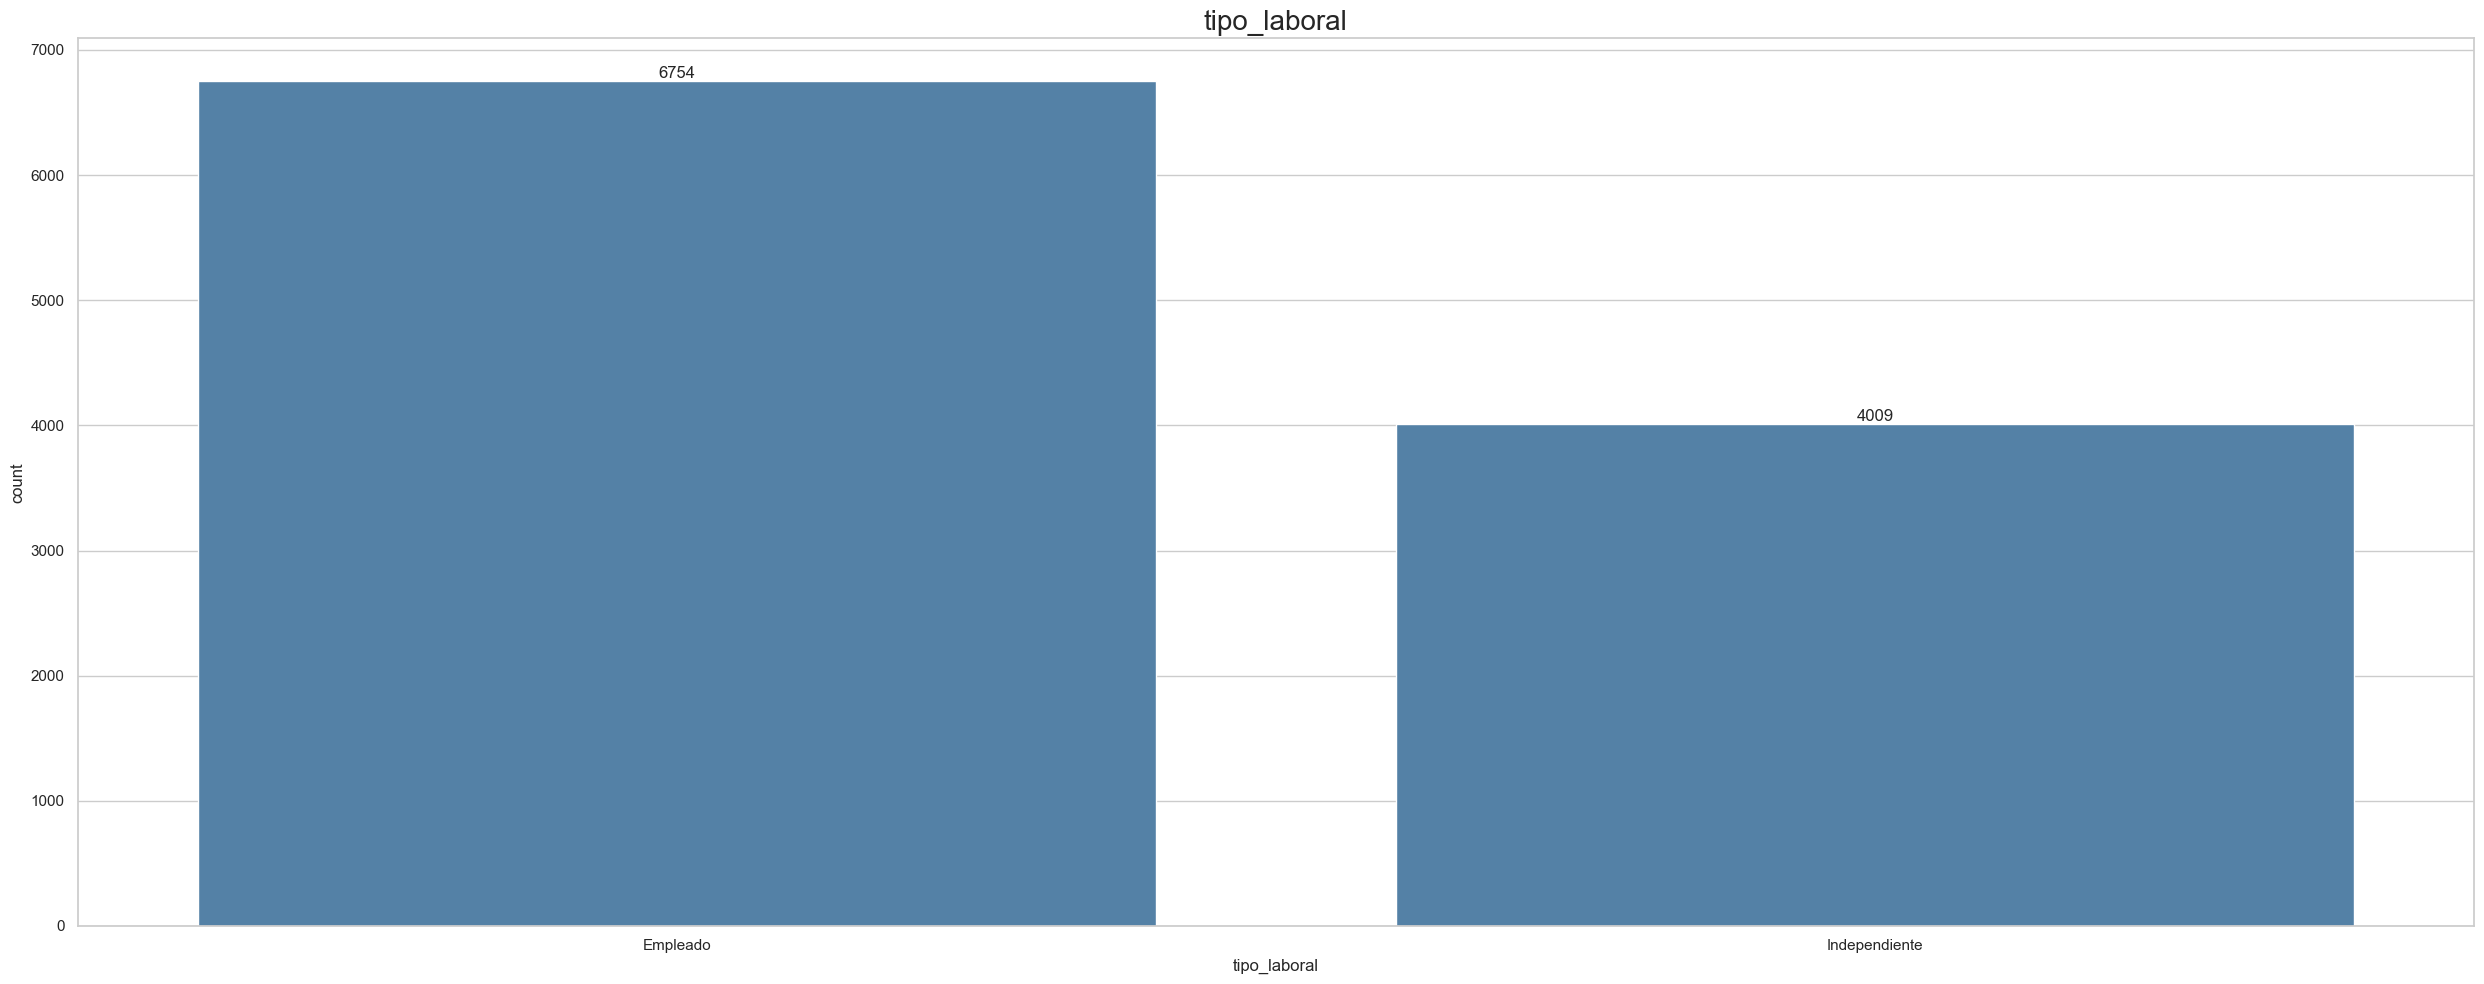


value_counts tipo_laboral:
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64


In [131]:
fig, axes = plt.subplots(figsize=(25, 10))

# tipo_laboral
sns.countplot(data=df, x='tipo_laboral', ax=axes, color='steelblue')
axes.set_title('tipo_laboral', fontsize=20)
for p in axes.patches:
    axes.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')


plt.tight_layout()
plt.show()

print("\nvalue_counts tipo_laboral:")
print(df['tipo_laboral'].value_counts())


**Interpretación:** La variable de tipo laboral se encuentra bastante balanceada entre empleados e independientes, no va a presentar un cesgo en el analisis. 

---
## Parte 3 — EDA: Análisis Bivariable (vs. Pago_atiempo)


### 3.1 Distribución del target (Pago_atiempo)


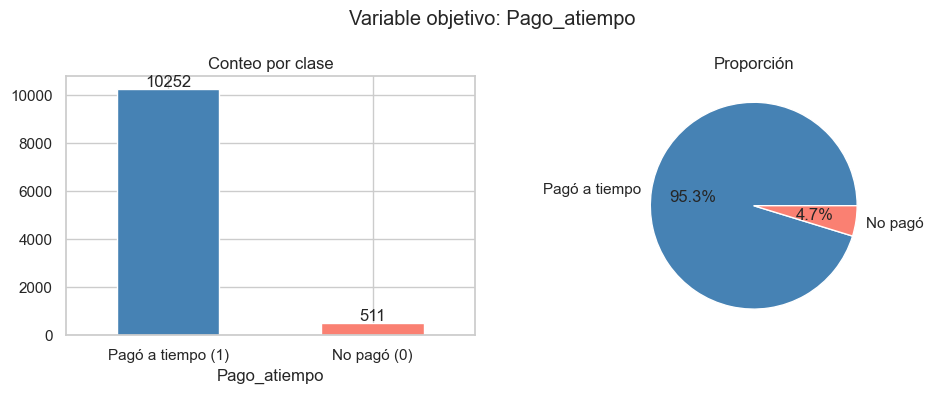

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

conteo = df['Pago_atiempo'].value_counts()
conteo.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Conteo por clase')
axes[0].set_xticklabels(['Pagó a tiempo (1)', 'No pagó (0)'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

conteo.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'salmon'],
            labels=['Pagó a tiempo', 'No pagó'])
axes[1].set_ylabel('')
axes[1].set_title('Proporción')

plt.suptitle('Variable objetivo: Pago_atiempo')
plt.tight_layout()
plt.show()


**Interpretación — Desbalance de clases:** El dataset está fuertemente desbalanceado: **95.3% pagó a tiempo** y solo **4.7% no pagó**. Esto es un hallazgo crítico para el modelado: el modelo tenderá a predecir siempre la clase mayoritaria. Se deberán aplicar técnicas como SMOTE, class_weight='balanced' o umbral de decisión ajustado en la etapa de entrenamiento.

**Regla de validación:** El porcentaje de mora nunca debería superar el 50% del total de registros. Actualmente está en 4.7%, lo cual es realista para una cartera crediticia saludable.


### 3.2 Variables numéricas vs Pago_atiempo (boxplots)


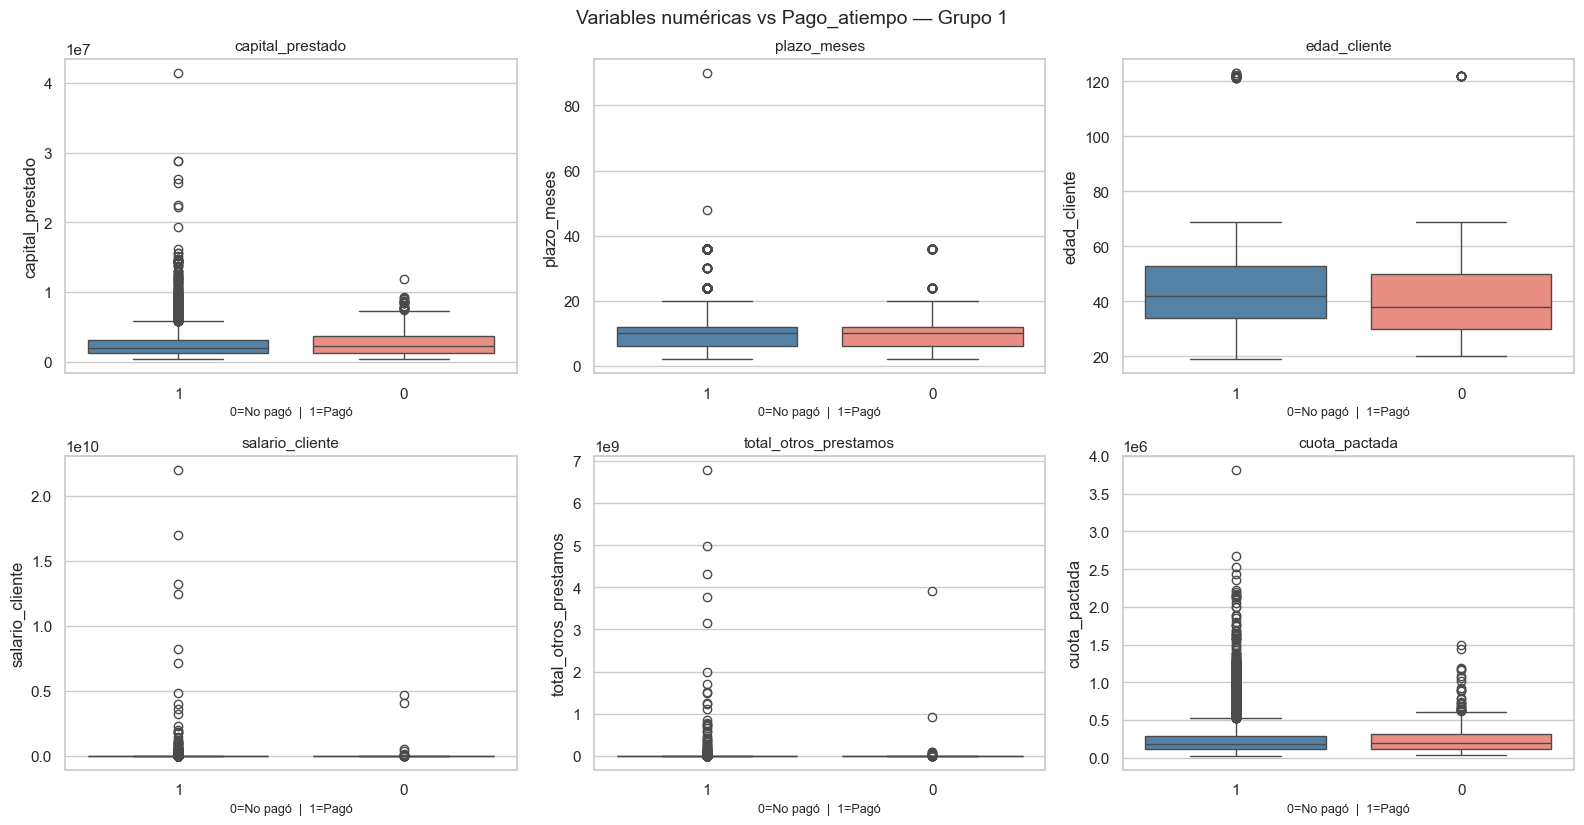

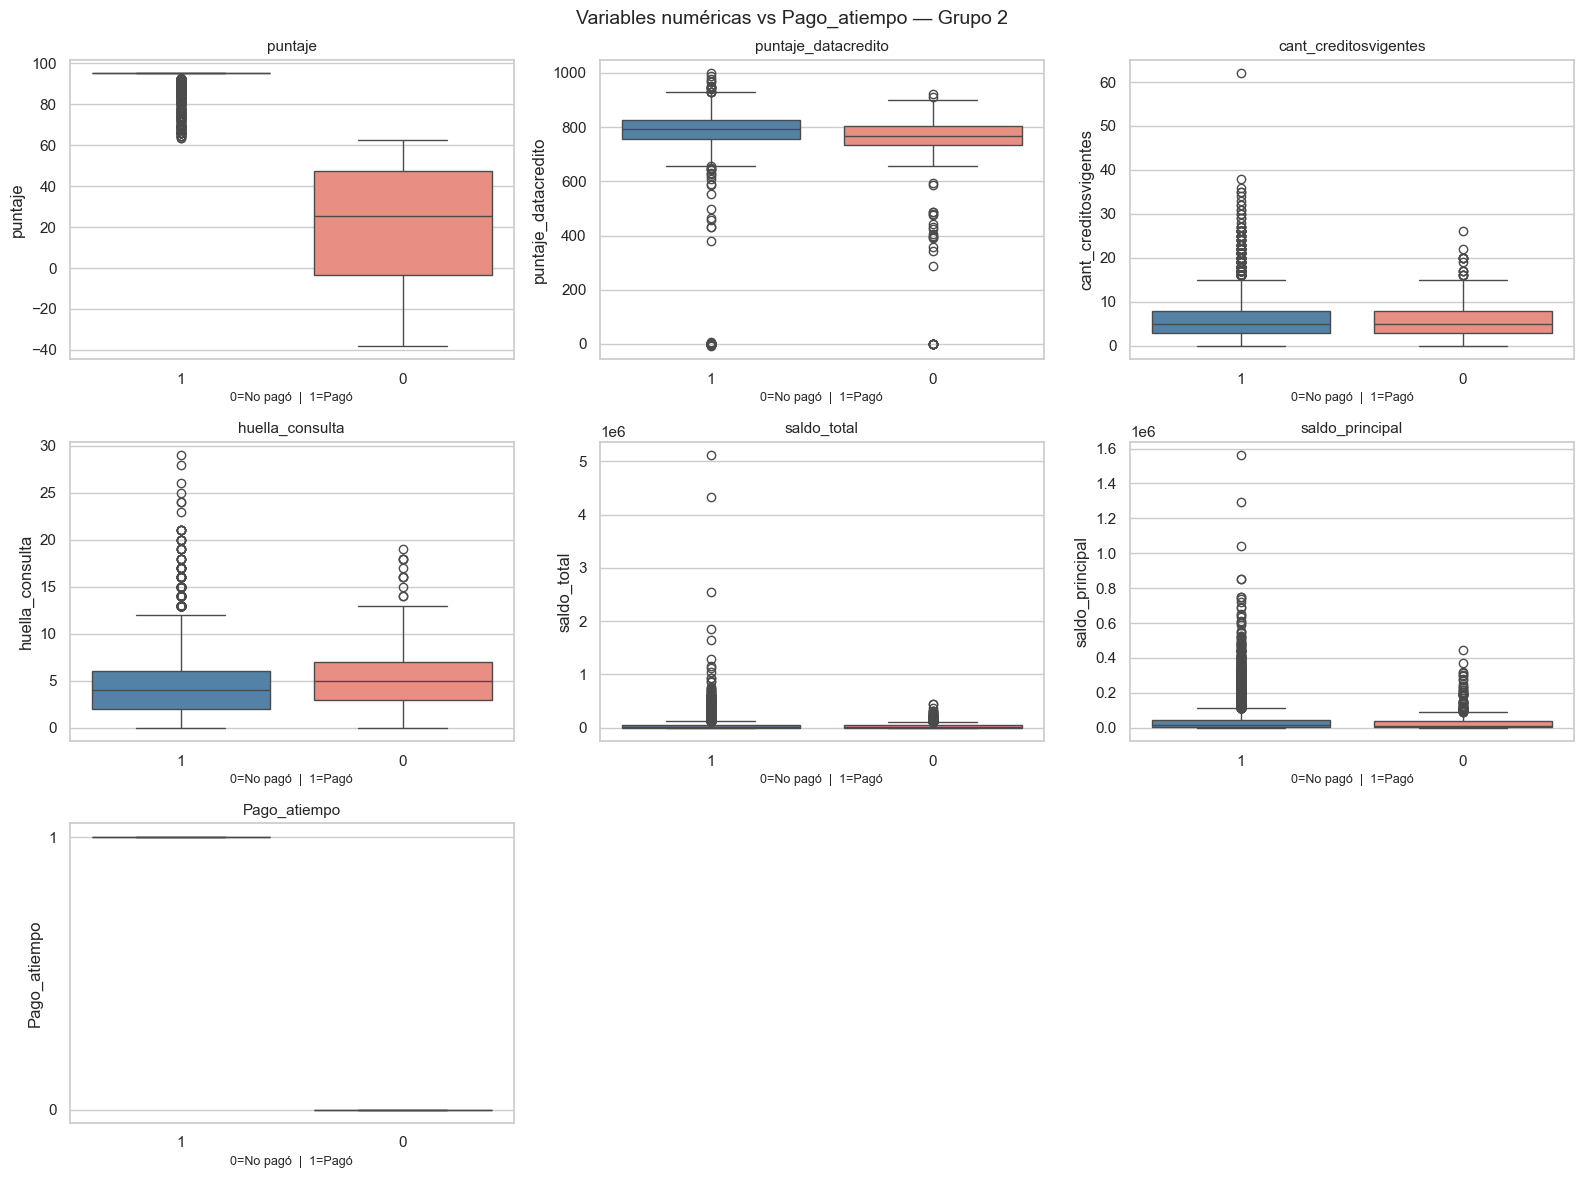

In [133]:
df_plot = df.copy()
df_plot['Pago_atiempo'] = df_plot['Pago_atiempo'].astype(str)

for idx, grupo in enumerate(grupos):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
    axes = axes.flatten()
    for i, col in enumerate(grupo):
        sns.boxplot(data=df_plot, x='Pago_atiempo', y=col, ax=axes[i],
                    hue='Pago_atiempo', palette={'0': 'salmon', '1': 'steelblue'}, legend=False)
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel('0=No pagó  |  1=Pagó', fontsize=9)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'Variables numéricas vs Pago_atiempo — Grupo {idx+1}', fontsize=14)
    plt.tight_layout()
    plt.show()


### 3.3 Variables categóricas vs Pago_atiempo (tablas pivote)


C:\Users\kikid\AppData\Local\Temp\ipykernel_18496\2810322629.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = df_tmp.groupby(col)['Pago_atiempo'].agg(['count', 'sum', 'mean']).rename(



=== tipo_laboral ===
               Total  Pagaron Tasa de pago  No pagaron
tipo_laboral                                          
Empleado        6754     6464        95.7%         290
Independiente   4009     3788        94.5%         221


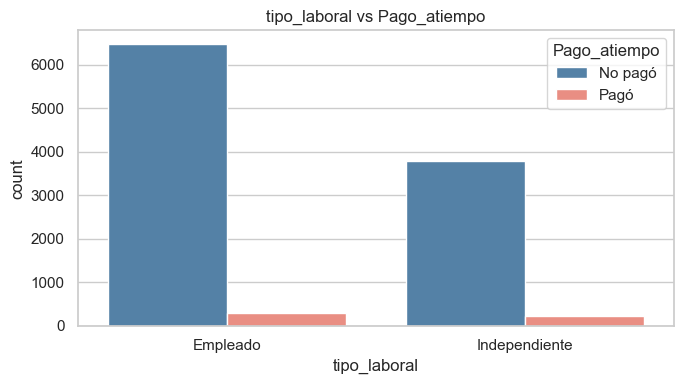

In [135]:
df_tmp = df.copy()
df_tmp['Pago_atiempo'] = df_tmp['Pago_atiempo'].astype(int)

for col in ['tipo_laboral']:
    tabla = df_tmp.groupby(col)['Pago_atiempo'].agg(['count', 'sum', 'mean']).rename(
        columns={'count': 'Total', 'sum': 'Pagaron', 'mean': 'Tasa de pago'}
    )
    tabla['No pagaron'] = tabla['Total'] - tabla['Pagaron']
    tabla['Tasa de pago'] = tabla['Tasa de pago'].map('{:.1%}'.format)
    print(f"\n=== {col} ===")
    print(tabla)

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.countplot(data=df_tmp.dropna(subset=[col]), x=col,
                  hue=df_tmp.loc[df_tmp[col].notna(), 'Pago_atiempo'].astype(str),
                  palette={'0': 'salmon', '1': 'steelblue'}, ax=ax)
    ax.set_title(f'{col} vs Pago_atiempo')
    ax.legend(title='Pago_atiempo', labels=['No pagó', 'Pagó'])
    plt.tight_layout()
    plt.show()


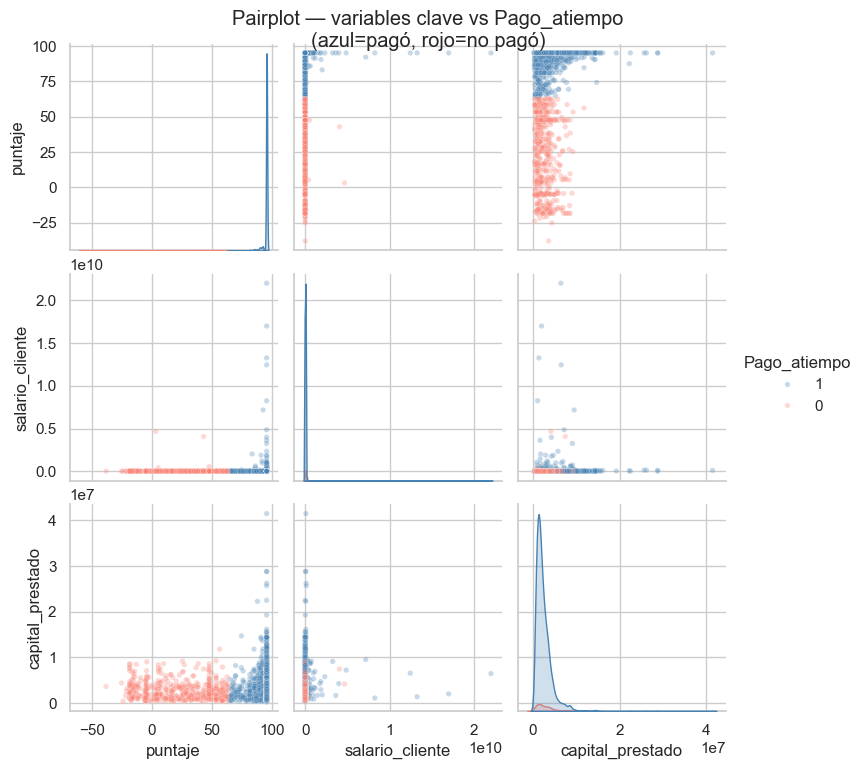

In [138]:
# 4 variables clave: las más relevantes para predecir el pago
# puntaje = score interno | salario = capacidad de pago | saldo_mora = mora actual | capital_prestado = tamaño del crédito
cols_pairplot = ['puntaje', 'salario_cliente', 'capital_prestado', 'Pago_atiempo']

df_pair = df[cols_pairplot].dropna().copy()
df_pair['Pago_atiempo'] = df_pair['Pago_atiempo'].astype(str)

# El pairplot muestra cada variable contra todas las demás.
# Diagonal: distribución de cada variable (azul=pagó, rojo=no pagó)
# Resto: scatter plot entre dos variables, coloreado por target
sns.pairplot(df_pair, hue='Pago_atiempo', palette={'0': 'salmon', '1': 'steelblue'},
             plot_kws={'alpha': 0.3, 's': 15}, diag_kind='kde', height=2.5)
plt.suptitle('Pairplot — variables clave vs Pago_atiempo\n(azul=pagó, rojo=no pagó)', y=1.02)
plt.show()


---
## Parte 5 — Conclusiones, Reglas de Validación y Transformaciones

### 5.1 Reglas de validación identificadas

Estas reglas deben usarse en el pipeline de validación de datos en producción:

| Regla | Descripción |
|-------|-------------|
| `edad_cliente >= 18` | Clientes menores de edad no deben existir |
| `salario_cliente > 0` | No puede haber salario negativo o cero |
| `capital_prestado > 0` | Todo préstamo debe tener capital positivo |
| `plazo_meses > 0` | El plazo debe ser mayor a cero |
| `cuota_pactada > 0` | La cuota debe ser positiva |
| `puntaje` entre 0 y 1000 | Rango válido de puntaje crediticio |
| `tipo_laboral` in ['Empleado', 'Independiente'] | Solo dos valores válidos |
| `tendencia_ingresos` in ['Creciente', 'Decreciente', 'Estable', NaN] | Solo categorías válidas |
| `Pago_atiempo` in [0, 1] | La variable objetivo es binaria |

### 5.2 Atributos derivados sugeridos

- `mes_prestamo`: mes de `fecha_prestamo` (captura estacionalidad)
- `anio_prestamo`: año del préstamo
- `ratio_cuota_salario`: `cuota_pactada / salario_cliente` (esfuerzo financiero)
- `ratio_mora_total`: `saldo_mora / saldo_total` (proporción de mora)
- `log_capital`: log1p(`capital_prestado`) para reducir asimetría
- `tiene_codeudor`: indicador binario basado en `saldo_mora_codeudor` no nulo

### 5.3 Transformaciones recomendadas para Feature Engineering

- **Imputación:** mediana para variables financieras, 'Sin_datos' para `tendencia_ingresos`
- **Log-transform:** `capital_prestado`, `saldo_mora`, `promedio_ingresos_datacredito`
- **Encoding:** One-Hot para `tipo_laboral`, Ordinal para `tendencia_ingresos`, Target encoding para `tipo_credito`
- **Escalado:** StandardScaler o RobustScaler (por outliers) para variables numéricas
- **Balanceo:** SMOTE o class_weight en el modelo por desbalance 95/5
